In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import optim

# For reproducability
torch.manual_seed(0)

# Full Description of the Convolutional Layer

In [14]:
layer = nn.Conv2d(in_channels = 3,
                  out_channels = 64,
                  kernel_size = (5, 5),
                  stride = 2,
                  padding = 1
                  )

# Closing the Loop on MNIST with Convolutional Networks

In [15]:
class MNISTConvNet(nn.Module):
  def __init__(self):
    super(MNISTConvNet, self).__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(1, 32, 5, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.conv2 = nn.Sequential(
        nn.Conv2d(32, 64, 5, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(7*7*64, 1024),
        nn.Dropout(0.5),
        nn.Linear(1024, 10)
    )

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    return self.fc1(x)

In [16]:
trainset = MNIST('.', train=True, download=True, 
                      transform=ToTensor())
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

100.0%
100.0%
100.0%
100.0%


In [ ]:
# Testing cpu training time
lr = 1e-4
num_epochs = 5

device = 'cpu'
model_nocuda = MNISTConvNet().to(device)

for epochs in range(num_epochs):
  running_loss = 0.0
  num_correct = 0
  for inputs, labels in trainloader:
    optimizer.zero_grad()
    outputs = model_nocuda(inputs.to(device))
    loss = loss_fn(outputs, labels.to(device))
    loss.backward()
    running_loss += loss.item()
    optimizer.step()
    _, idx = outputs.max(dim=1)
    num_correct += (idx == labels.to(device)).sum().item()
  print('Loss: {} Accuracy: {}'.format(running_loss/len(trainloader),
        num_correct/len(trainloader)))
  
  # 50s per epoch on CPU

Loss: 2.3040223223314102 Accuracy: 6.545842217484009
Loss: 2.304186747272386 Accuracy: 6.517057569296376
Loss: 2.3041690168604414 Accuracy: 6.462686567164179
Loss: 2.3042881862441105 Accuracy: 6.449893390191898
Loss: 2.3042327488409176 Accuracy: 6.454157782515991


In [26]:
lr = 1e-4
num_epochs = 40

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MNISTConvNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

In [ ]:
for epochs in range(num_epochs):
  running_loss = 0.0
  num_correct = 0
  for inputs, labels in trainloader:
    optimizer.zero_grad()
    outputs = model(inputs.to(device))
    loss = loss_fn(outputs, labels.to(device))
    loss.backward()
    running_loss += loss.item()
    optimizer.step()
    _, idx = outputs.max(dim=1)
    num_correct += (idx == labels.to(device)).sum().item()
  print('Loss: {} Accuracy: {}'.format(running_loss/len(trainloader),
        num_correct/len(trainloader)))
  
  # ~13s per epoch w/ CUDA

Loss: 2.2972321929707964 Accuracy: 8.02452025586354
Loss: 2.2873118782856827 Accuracy: 10.598081023454158
Loss: 2.2768253807320016 Accuracy: 13.297441364605543
Loss: 2.2655635861191414 Accuracy: 16.337953091684437
Loss: 2.253660073158329 Accuracy: 19.08955223880597
Loss: 2.239836144803175 Accuracy: 21.818763326226012
Loss: 2.224408115659441 Accuracy: 24.295309168443495
Loss: 2.2065716648915177 Accuracy: 26.649253731343283
Loss: 2.1856157705982104 Accuracy: 29.430703624733475
Loss: 2.1608783642112064 Accuracy: 31.767590618336886
Loss: 2.1316136670773473 Accuracy: 33.646055437100216
Loss: 2.0961909271252437 Accuracy: 35.25159914712154
Loss: 2.05240898600011 Accuracy: 37.28678038379531
Loss: 1.9997236510075487 Accuracy: 38.52558635394456
Loss: 1.933717794509839 Accuracy: 39.921108742004265
Loss: 1.8548093049256786 Accuracy: 40.862473347547976
Loss: 1.761012634742997 Accuracy: 41.85501066098081
Loss: 1.6522157171896017 Accuracy: 42.88272921108742
Loss: 1.5320137823060123 Accuracy: 44.03411

ACTUAL: 9
MODEL OUTPUT: 9


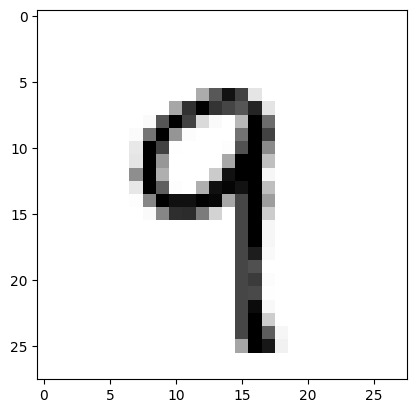

ACTUAL: 1
MODEL OUTPUT: 1


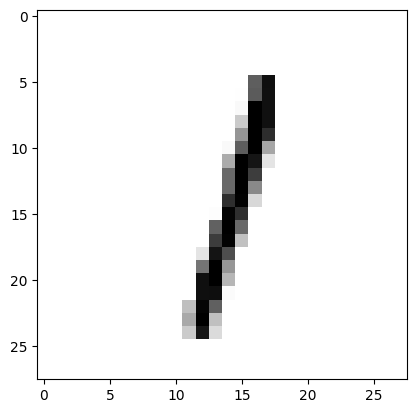

ACTUAL: 2
MODEL OUTPUT: 2


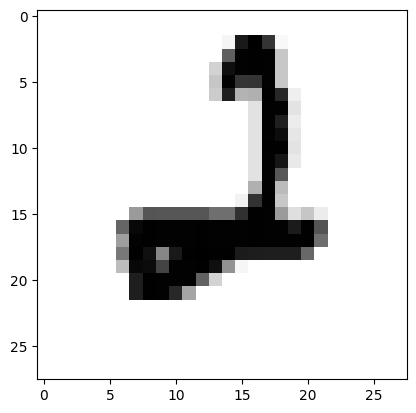

ACTUAL: 3
MODEL OUTPUT: 5


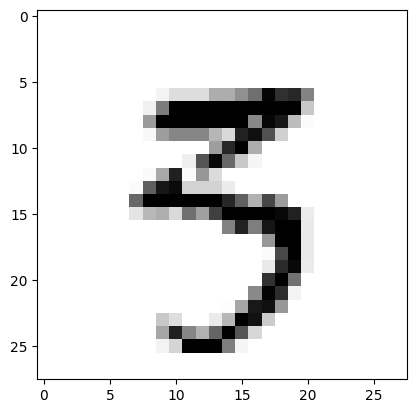

ACTUAL: 2
MODEL OUTPUT: 2


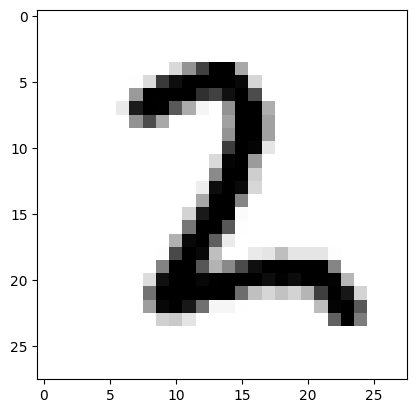

ACTUAL: 6
MODEL OUTPUT: 6


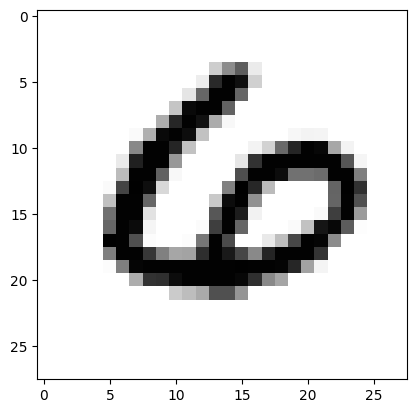

ACTUAL: 6
MODEL OUTPUT: 5


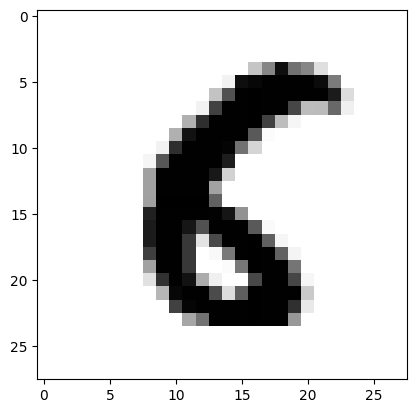

ACTUAL: 0
MODEL OUTPUT: 0


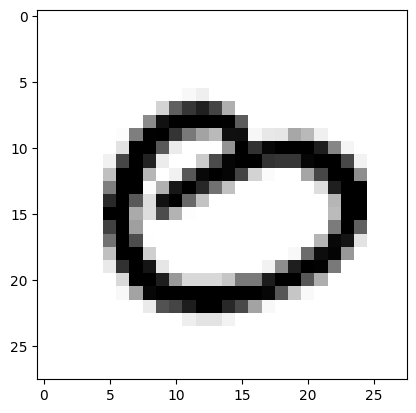

ACTUAL: 2
MODEL OUTPUT: 2


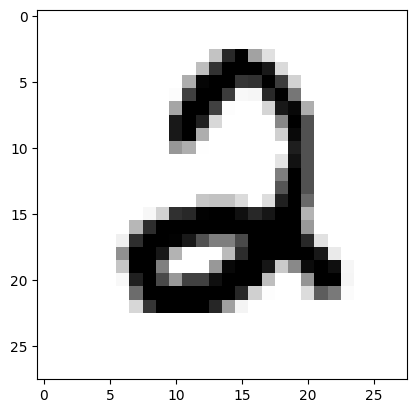

ACTUAL: 7
MODEL OUTPUT: 7


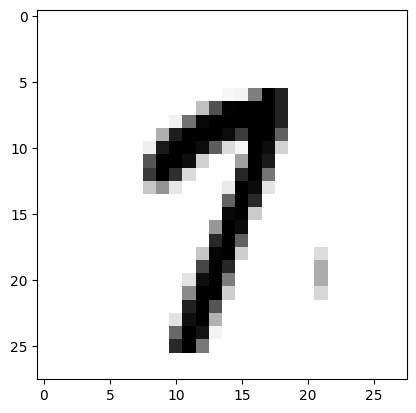

ACTUAL: 9
MODEL OUTPUT: 9


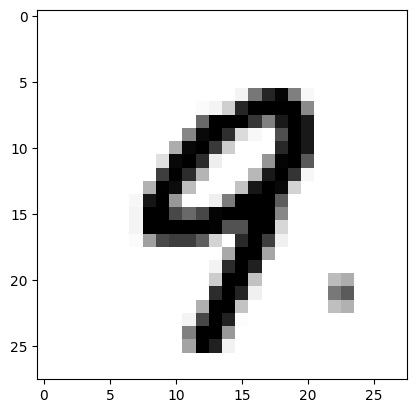

ACTUAL: 4
MODEL OUTPUT: 4


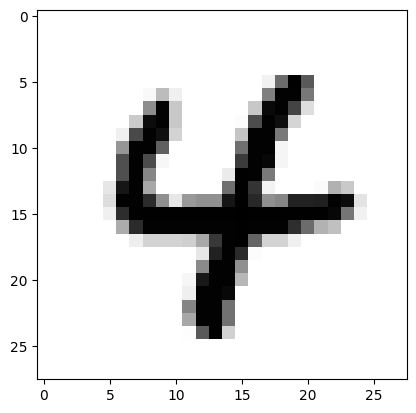

ACTUAL: 1
MODEL OUTPUT: 1


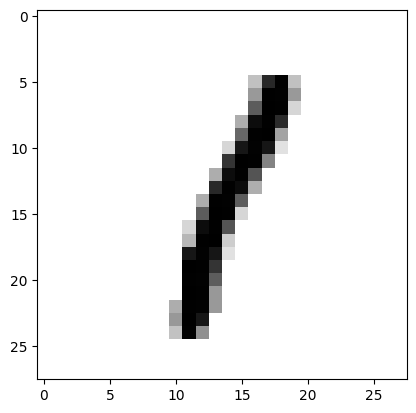

ACTUAL: 1
MODEL OUTPUT: 1


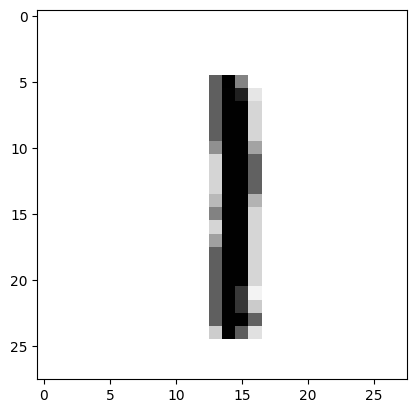

ACTUAL: 8
MODEL OUTPUT: 8


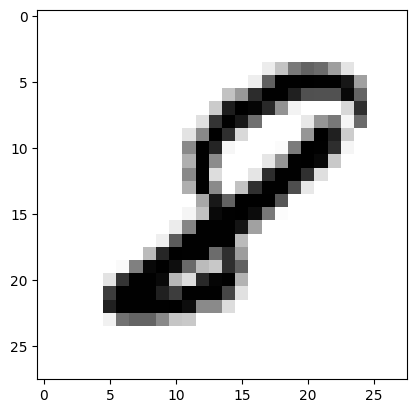

ACTUAL: 1
MODEL OUTPUT: 1


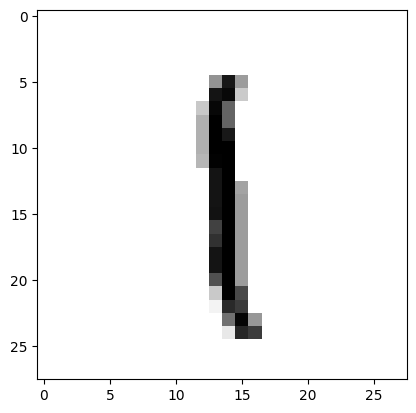

ACTUAL: 5
MODEL OUTPUT: 4


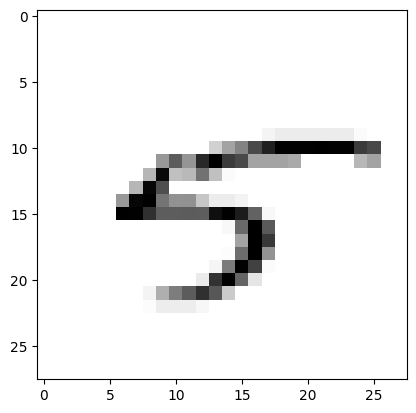

ACTUAL: 1
MODEL OUTPUT: 1


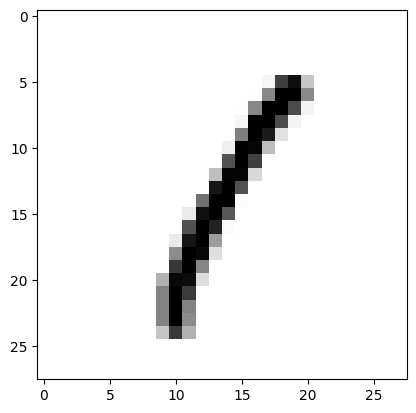

ACTUAL: 7
MODEL OUTPUT: 7


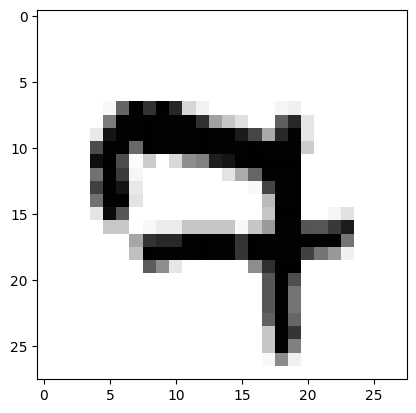

ACTUAL: 4
MODEL OUTPUT: 4


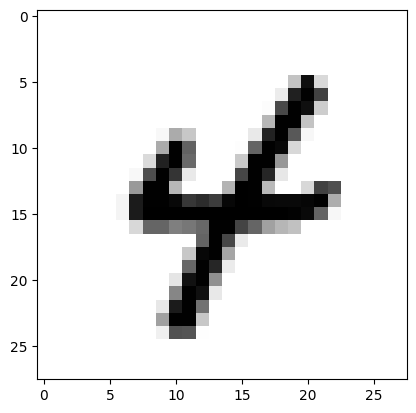

ACTUAL: 6
MODEL OUTPUT: 2


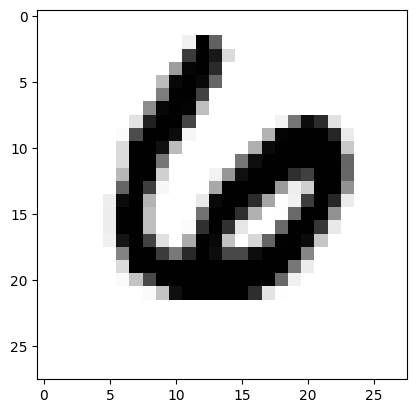

ACTUAL: 6
MODEL OUTPUT: 6


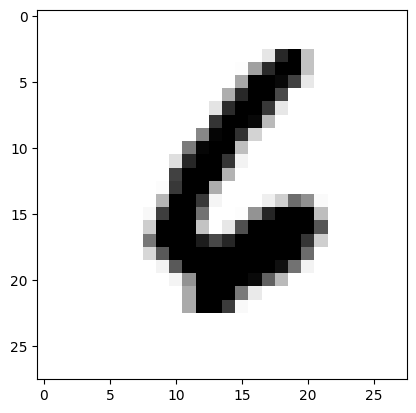

ACTUAL: 1
MODEL OUTPUT: 1


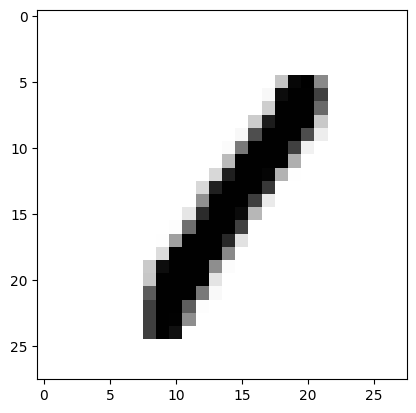

ACTUAL: 4
MODEL OUTPUT: 4


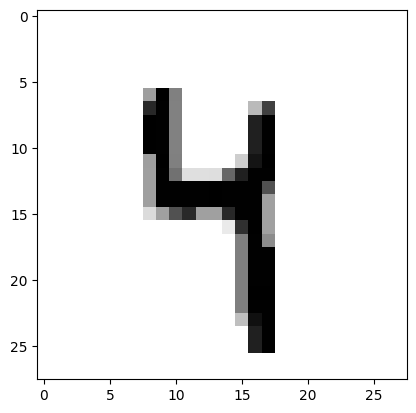

ACTUAL: 1
MODEL OUTPUT: 1


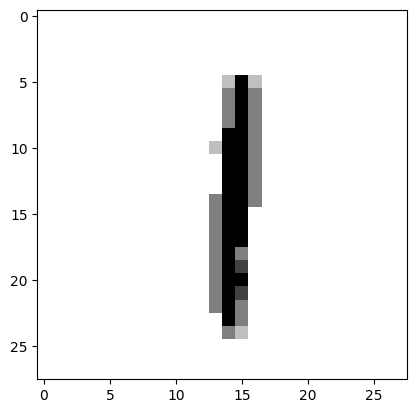

ACTUAL: 0
MODEL OUTPUT: 0


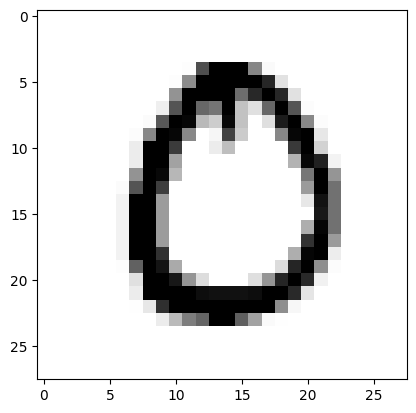

ACTUAL: 8
MODEL OUTPUT: 8


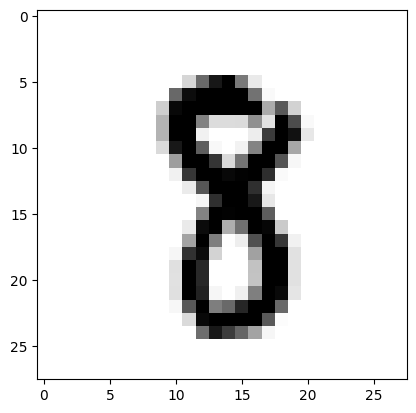

ACTUAL: 4
MODEL OUTPUT: 4


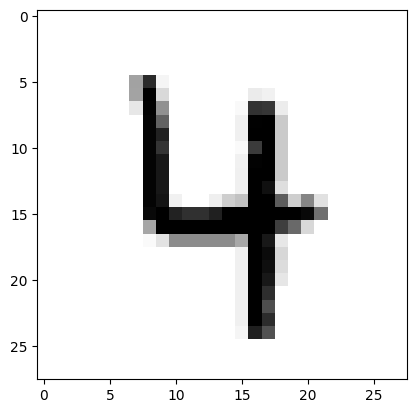

ACTUAL: 3
MODEL OUTPUT: 3


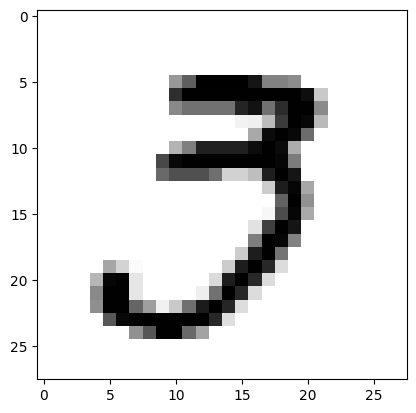

ACTUAL: 2
MODEL OUTPUT: 3


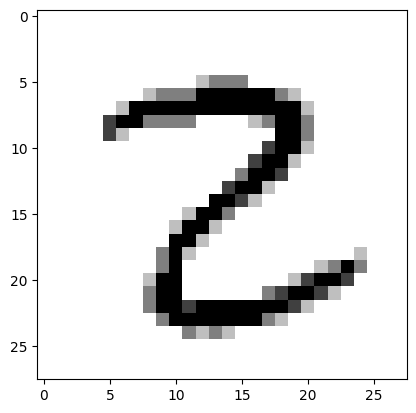

ACTUAL: 2
MODEL OUTPUT: 2


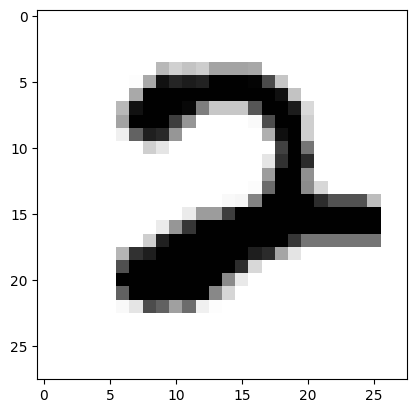

ACTUAL: 1
MODEL OUTPUT: 1


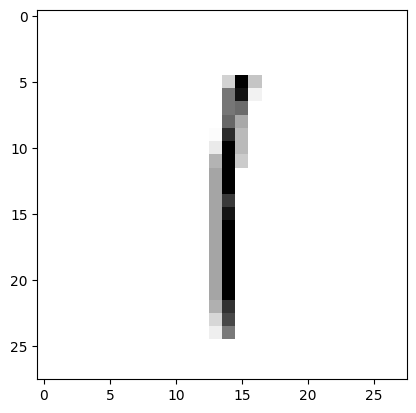

In [ ]:
import matplotlib.pyplot as plt
for i in range(32):
    print("ACTUAL:", labels.numpy()[i])
    print("MODEL OUTPUT:", idx.cpu().numpy()[i])
    plt.imshow(inputs.numpy()[i, 0], cmap='gray_r')
    plt.show()

# Image Preprocessing Pipelines Enable More Robust Models

In [100]:
from torchvision import transforms

transform = transforms.Compose([
      transforms.RandomCrop(224),
      transforms.RandomHorizontalFlip(),
      transforms.ColorJitter(brightness=0,
                             contrast=0,
                             saturation=0,
                             hue=0),
      transforms.ToTensor(),
      transforms.Normalize(mean = (0.1307,),
                           std = (0.3081,)
                           )
      ])

# Accelerating Training with Batch Normalization


In [9]:
layer = nn.BatchNorm2d(num_features=32,
                       eps=1e-05,
                       momentum=0.1,
                       affine = True,
                       track_running_stats = True)

In [10]:
layer = nn.BatchNorm1d(num_features=32)

#Group normalization for memory constrained learning tasks


In [11]:
layer = nn.GroupNorm(num_groups=1,
                     num_channels=32)

#Building a Convolutional Network for CIFAR-10


In [101]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.block2 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128,10),
            nn.BatchNorm1d(10)
        )

    def forward(self, x):
        x = self.block1(x)
        return self.block2(x)

# Building a residual network with superhuman vision

In [13]:
from torchvision.models import resnet34

model = resnet34()

In [14]:
class ResidualBlock(nn.Module):
  def __init__(self, in_layers, out_layers, downsample=None):
    super(ResidualBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_layers, out_layers,
                           kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(out_layers)
    self.conv2 = nn.Conv2d(out_layers, out_layers,
                           kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_layers)
    self.downsample = downsample
    self.relu = nn.ReLU(inplace=True)

  def forward(self, inp):
    # Residual block
    out = self.conv1(inp)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    
    if self.downsample:
      inp = self.downsample(inp)
    
    # Shortcut connection
    out += inp
    return out

In [15]:
downsample = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=1, stride=1, bias=False),
      nn.BatchNorm2d(128)
    )

In [16]:
class ResNet34(nn.Module):
  def __init__(self):
    super(ResNet34, self).__init__()

    self.conv1 = nn.Sequential(
      nn.Conv2d(3, 64, kernel_size=7,
                stride=2, padding=3, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=3,
                   stride=2, padding=1)
    )

    # Note that each ResidualBlock has 2 conv layers
    # 3 blocks in a row, 6 conv layers
    self.comp1 = nn.Sequential(
      ResidualBlock(64, 64),
      ResidualBlock(64, 64),
      ResidualBlock(64, 64)
    )

    # 4 blocks in a row, 8 conv layers
    downsample1 = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=1,
             stride=1, bias=False),
      nn.BatchNorm2d(128)
    )
    self.comp2 = nn.Sequential(
      ResidualBlock(64, 128, downsample=downsample1),
      ResidualBlock(128, 128),
      ResidualBlock(128, 128),
      ResidualBlock(128, 128)
    )
    
    # 6 blocks in a row, 12 conv layers
    downsample2 = nn.Sequential(
      nn.Conv2d(128, 256, kernel_size=1, stride=1, bias=False),
      nn.BatchNorm2d(256)
    )
    self.comp3 = nn.Sequential(
      ResidualBlock(128, 256, downsample=downsample2),
      ResidualBlock(256, 256),
      ResidualBlock(256, 256),
      ResidualBlock(256, 256),
      ResidualBlock(256, 256),
      ResidualBlock(256, 256),
    )
    
    # 3 blocks in a row, 6 conv layers
    downsample3 = nn.Sequential(
      nn.Conv2d(256, 512, kernel_size=1, stride=1, bias=False),
      nn.BatchNorm2d(512)
    )
    self.comp4 = nn.Sequential(
      ResidualBlock(256, 512, downsample=downsample3),
      ResidualBlock(512, 512),
      ResidualBlock(512, 512)   
    )

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    # ImageNet classifier: 1000 classes
    self.fc = nn.Linear(512, 1000)

  def forward(self, inp):
    out = self.conv1(inp)
    
    out = self.comp1(out)
    out = self.comp2(out)
    out = self.comp3(out)
    out = self.comp4(out)

    out = self.avgpool(out)
    out = torch.flatten(out, 1)
    out = self.fc(out)

    return out